# Lab Assignment Six: Convolutional Network Architectures
### *Davis Lynn, Bonita Davis, Christopher Cook, Anekah Kelley*
## 1. Preparation
For Lab 6, we have chosen to use a dataset containing approximately 11,700 images of characters from the renowned anime series One Piece.

There are about 650 images each of 18 One Piece characters included in this dataset: Ace, Akainu, Brook, Chopper, Crocodile, Franky, Jinbei, Kurohige, Law, Luffy, Mihawk, Nami, Rayleigh, Robin, Sanji, Shanks, Usopp, and Zoro. These images were sourced through Google and Bing search engines. Some of these images were transformed through techniques such as color inversion and image rotation. Additionally, some of the images were cropped to eliminate unnecessary noise. The dataset can be downloaded for free on Kaggle through the link below.

Data Source: https://www.kaggle.com/datasets/ibrahimserouis99/one-piece-image-classifier?resource=download

The prediction task we have selected is to classify each of these images by the character shown in the image. The large amount of images provided through this dataset will be an excellent way to train our convolutional neural network to complete this prediction task.

The primary business case of our prediction task is streamlining processes in the entertainment and media industry. Streaming platforms, network websites, e-commerce websites, and more platforms will be able to organize its content by character automatically by using this convolutional neural network, which is much more efficient than sorting through millions of images manually. A direct use case for this neural network is enhancing user search experiences by allowing users to search for an episode by character. Additionally, e-commerce sites would have improved inventory management systems through easy lookups by character. Additionally, studios can use data gathered with the help of this classifier to analyze the popularity of characters and adjust marketing strategies and become more successful.

### 1.1 Performance Evaluation Metric
For our convolutional neural network (CNN) and multi-layer perceptron (MLP) models, we will evaluate the performance using accuracy and Area Under the Curve (AUC). 

While it is true that accuracy is not always the most appropriate performance evaluation metric, we chose to use accuracy because class imbalance is not a concern in this dataset. A potential issue with using accuracy is being overly influenced by the majority class in an imbalanced dataset. However, this dataset includes approximately 650 images for each character class, ensuring a balanced representation.

Furthermore, accuracy works well with our prediction task. Our prediction task is to classify images of One Piece characters into one of 18 classes, and our primary goal is to maximize the number of correct classifications. Accuracy gives the most direct way of measuring this objective by providing the proportion of correctly classified images out of all predictions.

In addition to accuracy, we will also evaluate AUC. AUC provides a more nuanced performance evaluation, particularly in distinguishing between classes at various decision thresholds. While accuracy measures the overall correctness, AUC focuses on the model's ability to discriminate between classes, making it an ideal metric for understanding how well the model performs across different thresholds.

Accuracy provides a clear and easily interpretable measure of model performance for stakeholders in the media and entertainment industry, making it a valuable metric for business cases mentioned above, such as user search optimization and character-based content indexing. AUC complements this by offering a more holistic evaluation of model performance, allowing us to assess the classifier's robustness in distinguishing between classes even when thresholds vary. Therefore, both accuracy and AUC together offer a comprehensive evaluation for our prediction task.

### 1.2 Data Division Method
We chose to divide our data using stratified 10-fold cross-validation because this method is best suited for our prediction task. Stratified 10-fold cross-validation ensures that each fold in the cross-validation process maintains the same proportion of samples from each class as in the full dataset. Since we have 18 character classes, this method ensures that each training and test subset is representative of the overall distribution of characters. This is important as we want to ensure the model is trained and tested on balanced data to avoid any potential biases that could happen if there were classes that are underrepresented in certain folds.

Furthermore, by using stratified 10-fold cross-validation, we ensure that every data point is used both for training and testing across different folds, allowing the model to be evaluated on multiple splits of the data. This reduces the variance of the performance estimate, providing a more reliable understanding of how the model will perform on unseen data. With 10 folds, each model is tested on a different partition, and we can compute an average accuracy (and AUC score) across all folds to get a more stable performance metric.

Stratified 10-fold cross-validation is a realistic mirroring of how an algorithm would be evaluated in practice, especially when the goal is to ensure the model generalizes well to unseen data. In real-world applications, models are often deployed to classify new, unseen data. By using this method, we mimic this process by repeatedly testing the model on data that it had not seen during training. This iterative testing approach helps to evaluate how well the model generalizes across different subsets of the dataset and provides a realistic simulation of how the model would be deployed.

## 2. Modeling
### 2.1 Data Expansion in Keras
For this task, we will utilize data augmentation techniques in Keras to artificially expand our training dataset by applying random transformations to the images during training. Data augmentation helps to prevent overfitting, improve generalization, and create more robust models by increasing the variability in the dataset without the need for additional data collection.

In our setup, we are using two key data augmentation techniques: RandomFlip and RandomRotation. RandomFlip randomly flips the images horizontally during training. This is appropriate for our dataset because the characters in the One Piece images often have nearly symmetrical faces or features. Therefore, flipping the image horizontally should not significantly alter the character's identity. By using flipped images, the model learns to recognize characters from different orientations, making it more robust in its ability to recognize the same character from various perspectives.

RandomRotation will apply a random rotation of up to 20% of the image's original angle. This technique is useful for simulating variations in how the images of characters may appear in real-world applications where the orientation of the image may vary. Rotating the images helps the model learn to recognize characters from more perspectives, further improving its ability to generalize to new, unseen data.

Data augmentation is useful for our dataset and prediction task because the goal of our model is to improve the model's ability to classify images accurately under different conditions, such as different angles and orientations. These augmentation techniques are appropriate as they cause slight but meaningful variations to the images while preserving the identity of the characters in the images. By using these data augmentation techniques, we are artificially expanding the dataset, allowing the model to learn more robust features and reducing the risk of overfitting.

In [18]:
import keras
import os
import struct
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, MaxPooling2D, Conv2D, Dense, Flatten, Activation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
import cv2
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Input
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import average 
from tensorflow.keras.models import  Model

In [19]:
def load_dataset(path):
    images = []
    labels = []
    label_classes = os.listdir(path)
    for label in label_classes:
        img_names = os.listdir(os.path.join(path, label))
        for img_name in img_names:
            img_path = os.path.join(path, label, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue
            img = cv2.resize(img, (28, 28))
            images.append(img)
            labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    return images, labels

X, y = load_dataset('Data/Data')

In [20]:
# Normalize the images.
X = X.reshape(X.shape[0], 28, 28, 1) / 255.0 - 0.5

# Use LabelEncoder to encode labels into integers
le = LabelEncoder()
y = le.fit_transform(y)

# Number of classes
NUM_CLASSES = len(np.unique(y))

# One-hot encode the labels
y_ohe = to_categorical(y, NUM_CLASSES)

In [21]:
%matplotlib inline

def compare_mlp_cnn(cnn, mlp, X_test, y_test, labels='auto'):
    plt.figure(figsize=(15,5))
    if cnn is not None:
        yhat_cnn = np.argmax(cnn.predict(X_test), axis=1)
        
        
        y_test_int = np.argmax(y_test, axis=1)  # Convert y_test to integer labels
        acc_cnn = mt.accuracy_score(y_test_int,yhat_cnn)
        
        
        # acc_cnn = mt.accuracy_score(y_test,yhat_cnn)
        plt.subplot(1,2,1)
        # cm = mt.confusion_matrix(y_test,yhat_cnn)
        cm = mt.confusion_matrix(y_test_int,yhat_cnn)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title(f'CNN: {acc_cnn:.4f}')
    
    if mlp is not None:
        yhat_mlp = np.argmax(mlp.predict(X_test), axis=1)
        
        
        y_test_int = np.argmax(y_test, axis=1)  # Convert y_test to integer labels
        acc_mlp = mt.accuracy_score(y_test_int,yhat_cnn)
        
        
        # acc_mlp = mt.accuracy_score(y_test,yhat_mlp)
        
        plt.subplot(1,2,2)
        cm = mt.confusion_matrix(y_test_int,yhat_mlp)
        # cm = mt.confusion_matrix(y_test,yhat_mlp)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm,annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title(f'MLP: {acc_mlp:.4f}')
labels = [
    "Ace", "Akainu", "Brook", "Chopper", "Crocodile", "Franky", "Jinbei",
    "Kurohige", "Law", "Luffy", "Mihawk", "Nami", "Rayleigh", "Robin",
    "Sanji", "Shanks", "Usopp", "Zoro"
]

In [22]:
# %%time
# Define data augmentation

data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
])
# make a keras MLP
def createMLP():
        mlp = Sequential()
        mlp.add(data_augmentation)
        mlp.add( Flatten() )
        mlp.add( Dense(input_dim=1, units=100, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(NUM_CLASSES) )
        mlp.add( Activation('softmax') )

        mlp.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

        input_shape = [None, 28,28,1]
        mlp.build(input_shape)
        return mlp

### 2.2 Convolutional Neural Network Architectures

### CNN1
#### Architecture Overview
1. Data Augmentation
2. Convolutional Blocks (x2):
   - Conv2D: 24 filters, 3x3 kernel, 'same' padding
   - ReLU activation
   - MaxPooling2D: 2x2
3. Dense Layers:
   - Flatten
   - Dense(100, ReLU)
   - Dense(100, ReLU)
   - Dense(NUM_CLASSES, softmax)

#### Key Features
- Simple symmetric design
- Mean squared error loss
- RMSprop optimizer
- No dropout layers

### CNN2
#### Architecture Overview
1. Data Augmentation
2. First Conv Block:
   - Conv2D: 32 filters, 3x3 kernel
3. Second Conv Block:
   - Conv2D: 64 filters, 3x3 kernel
   - MaxPooling2D: 2x2
4. Dense Block:
   - Dropout(0.25)
   - Flatten
   - Dense(128, ReLU)
   - Dropout(0.5)
   - Dense(NUM_CLASSES, softmax)

#### Key Features
- AlexNet inspired
- Categorical crossentropy loss
- RMSprop optimizer
- Regular dropout layers

### CNN3
#### Architecture Overview
1. Data Augmentation
2. Convolutional Blocks (x2):
   - Conv2D: 32 filters, 5x5 kernel
   - ReLU activation
   - MaxPooling2D: 2x2
3. Dense Layers:
   - Flatten
   - Dense(128, ReLU)
   - Dense(128, ReLU)
   - Dense(NUM_CLASSES, softmax)

#### Key Features
- Wider kernels (5x5)
- Mean squared error loss
- Adam optimizer
- No dropout

### CNN4
#### Architecture Overview
1. Data Augmentation
2. First Conv Block:
   - Conv2D: 48 filters, 5x5 kernel
3. Second Conv Block:
   - Conv2D: 96 filters, 5x5 kernel
   - MaxPooling2D: 2x2
4. Dense Block:
   - Dropout(0.3)
   - Flatten
   - Dense(256, ReLU)
   - Dropout(0.5)
   - Dense(NUM_CLASSES, softmax)

#### Key Features
- Progressive filter increase
- Categorical crossentropy loss
- Adam optimizer
- Dual dropout layers


In [23]:
def createCNN1():
    cnn1 = Sequential()
    cnn1.add(data_augmentation)
    num_filt_layers = [24, 24]
    for num_filters in num_filt_layers:
        cnn1.add( Conv2D(filters=num_filters, 
                        kernel_size=(3,3), 
                        padding='same') )
        cnn1.add( Activation('relu'))
        cnn1.add( MaxPooling2D(pool_size=(2, 2), 
                            ) )
        

    # add one layer on flattened output
    cnn1.add( Flatten() )
    cnn1.add( Dense(100, activation='relu') )
    cnn1.add( Dense(100, activation='relu') )
    cnn1.add( Dense(NUM_CLASSES, activation='softmax') )
    
    cnn1.compile(loss='mean_squared_error',
              optimizer='rmsprop',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])  
    input_shape = [None, 28,28,1]
    cnn1.build(input_shape)  
    return cnn1

def createCNN2():
    cnn2 = Sequential()
    cnn2.add(data_augmentation)
    # let's start with an AlexNet style convolutional phase
    cnn2.add(Conv2D(filters=32,
                    input_shape = (28,28,1),
                    kernel_size=(3,3), 
                    padding='same', 
                    activation='relu')) # more compact syntax

    # no max pool before next conv layer!!
    cnn2.add(Conv2D(filters=64,
                    kernel_size=(3,3), 
                    padding='same', 
                    activation='relu')) # more compact syntax
    cnn2.add(MaxPooling2D(pool_size=(2, 2)))
        

    # add one layer on flattened output
    cnn2.add(Dropout(0.25)) # add some dropout for regularization after conv layers
    cnn2.add(Flatten())
    cnn2.add(Dense(128, activation='relu'))
    cnn2.add(Dropout(0.5)) # add some dropout for regularization, again!
    cnn2.add(Dense(NUM_CLASSES, activation='softmax'))

    # Let's train the model 
    cnn2.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
                optimizer='rmsprop', # 'adadelta' 'rmsprop'
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    input_shape = [None, 28,28,1]
    cnn2.build(input_shape)  
    return cnn2
    
def createCNN3():
    cnn3 = Sequential()
    cnn3.add(data_augmentation)
    num_filt_layers = [32, 32]  # Changed number of filters
    for num_filters in num_filt_layers:
        cnn3.add(Conv2D(filters=num_filters, 
                        kernel_size=(5,5),  # Changed kernel size
                        padding='same'))
        cnn3.add(Activation('relu'))
        cnn3.add(MaxPooling2D(pool_size=(2, 2)))

    # add one layer on flattened output
    cnn3.add(Flatten())
    cnn3.add(Dense(128, activation='relu'))  # Changed number of neurons
    cnn3.add(Dense(128, activation='relu'))  # Changed number of neurons
    cnn3.add(Dense(NUM_CLASSES, activation='softmax'))
    
    cnn3.compile(loss='mean_squared_error',
              optimizer='adam',  # Changed optimizer
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])  
    input_shape = [None, 28,28,1]
    cnn3.build(input_shape)  
    return cnn3

def createCNN4():
    cnn4 = Sequential()
    cnn4.add(data_augmentation)
    cnn4.add(Conv2D(filters=48,  # Changed number of filters
                    input_shape = (28,28,1),
                    kernel_size=(5,5),  # Changed kernel size
                    padding='same', 
                    activation='relu'))

    cnn4.add(Conv2D(filters=96,  # Changed number of filters
                    kernel_size=(5,5),  # Changed kernel size
                    padding='same', 
                    activation='relu'))
    cnn4.add(MaxPooling2D(pool_size=(2, 2)))

    cnn4.add(Dropout(0.3))  # Changed dropout rate
    cnn4.add(Flatten())
    cnn4.add(Dense(256, activation='relu'))  # Changed number of neurons
    cnn4.add(Dropout(0.5)) 
    cnn4.add(Dense(NUM_CLASSES, activation='softmax'))

    cnn4.compile(loss='categorical_crossentropy',
                optimizer='adam',  # Changed optimizer
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    input_shape = [None, 28,28,1]
    cnn4.build(input_shape)  
    return cnn4

In [24]:
import matplotlib.pyplot as plt

def plot_histories(histories, labels):
    # Create new labels list with labels for both training and validation lines
    # new_labels = [f'{label} Train' for label in labels] + [f'{label} Validation' for label in labels]
    new_labels = [f'{labels[i//2]} {["Train", "Validation"][i%2]}' for i in range(2*len(labels))]
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(new_labels, loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(new_labels, loc='upper left')
    plt.show()

In [25]:
# %%time
# Define data augmentation

data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
])
# make a keras MLP
def createMLP():
        mlp = Sequential()
        mlp.add(data_augmentation)
        mlp.add( Flatten() )
        mlp.add( Dense(input_dim=1, units=100, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(NUM_CLASSES) )
        mlp.add( Activation('softmax') )

        mlp.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

        input_shape = [None, 28,28,1]
        mlp.build(input_shape)
        return mlp

        # mlp.fit(X_train, y_train_ohe, 
        #         batch_size=32, epochs=3, 
        #         shuffle=True, verbose=1)

In [26]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


def TransferCNN():
    # Load pre-trained MobileNet model without the top layers
    data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
    ])
    
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

    # Add a global spatial average pooling layer
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Add a fully-connected layer
    x = Dense(1024, activation='relu')(x)

    # Add a logistic layer with the number of classes
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    # Define the model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model = Sequential([
        data_augmentation,
        model
    ])

    # Freeze the layers of the base model (we won't update the weights during training)
    for layer in base_model.layers:
        layer.trainable = False

    # Compile the model
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    return model

X_train shape: (5868, 28, 28, 1)
X_test shape: (5869, 28, 28, 1)
y_train shape: (5868, 18)
y_test shape: (5869, 18)
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step


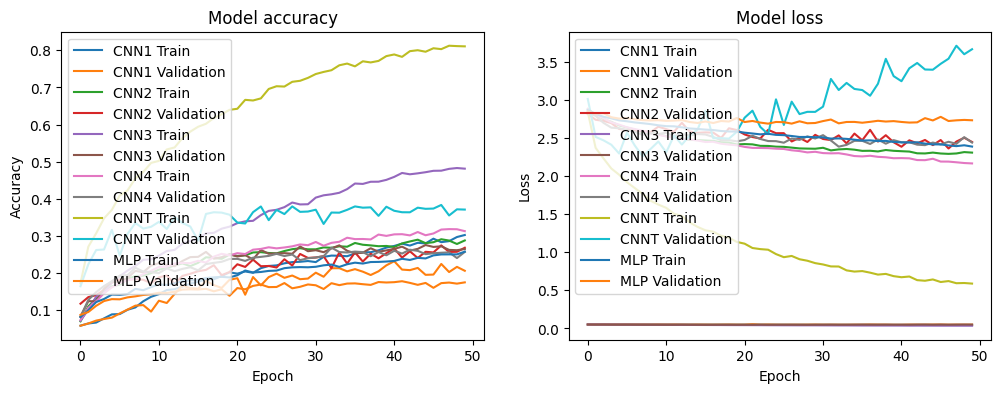

X_train shape: (5869, 28, 28, 1)
X_test shape: (5868, 28, 28, 1)
y_train shape: (5869, 18)
y_test shape: (5868, 18)
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step


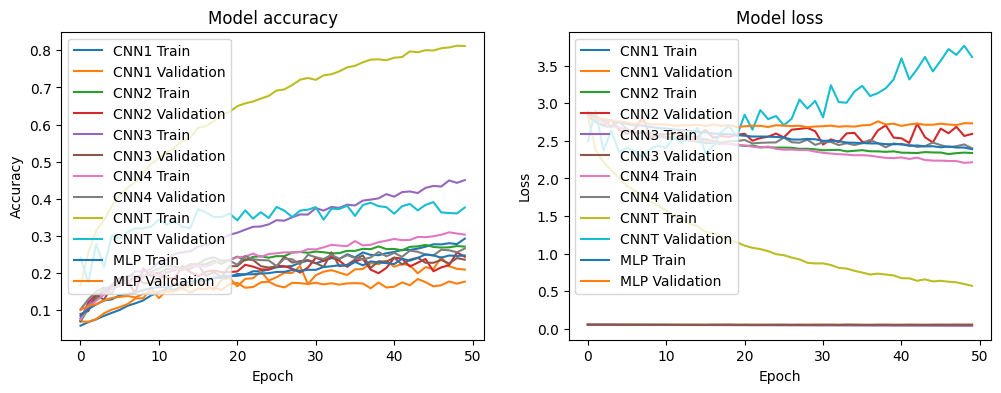

In [30]:
from sklearn.metrics import roc_auc_score

# Stratified 10-fold cross-validation
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cnn1_accuracies = []
cnn2_accuracies = []
cnn3_accuracies = []
cnn4_accuracies = []
cnnT_accuracies = []
mlp_accuracies = []
cnn1_auc_scores = []
cnn2_auc_scores = []
cnn3_auc_scores = []
cnn4_auc_scores = []
cnnT_auc_scores = []
mlp_auc_scores = []
#use this for training the thing
es = 50
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_ohe[train_index], y_ohe[test_index]
    print('X_train shape:', X_train.shape) 
    print('X_test shape:', X_test.shape)

    print('y_train shape:', y_train.shape) 
    print('y_test shape:', y_test.shape)
    # Train and evaluate the first CNN
    cnn1 = createCNN1()
    history1 = cnn1.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn1_accuracies.append(history1.history['val_accuracy'][-1])
    y_pred_probs = cnn1.predict(X_test)  # Predict the probabilities of the positive class
    cnn1_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn1_auc_scores.append(history1.history['val_auc'][-1])  # Extract AUC from history


    # Train and evaluate the second CNN
    cnn2 = createCNN2()
    history2 = cnn2.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn2_accuracies.append(history2.history['val_accuracy'][-1])
    y_pred_probs = cnn2.predict(X_test)  # Predict the probabilities of the positive class
    cnn2_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn2_auc_scores.append(history2.history['val_auc'][-1])  # Extract AUC from history
    
    # Train and evaluate the third CNN
    cnn3 = createCNN3()
    history3 = cnn3.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn3_accuracies.append(history3.history['val_accuracy'][-1])
    y_pred_probs = cnn3.predict(X_test)  # Predict the probabilities of the positive class
    cnn3_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn3_auc_scores.append(history3.history['val_auc'][-1])

    # Train and evaluate the fourth CNN
    cnn4 = createCNN4()
    history4 = cnn4.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn4_accuracies.append(history4.history['val_accuracy'][-1])
    y_pred_probs = cnn4.predict(X_test)  # Predict the probabilities of the positive class
    cnn4_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn4_auc_scores.append(history4.history['val_auc'][-1])

    # Train and evaluate the MLP
    mlp = createMLP()
    # history_mlp = mlp.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0)
    history_mlp = mlp.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test, y_test))
    mlp_accuracies.append(history_mlp.history['val_accuracy'][-1])
    y_pred_probs = mlp.predict(X_test)  # Predict the probabilities of the positive class
    mlp_auc_scores.append(roc_auc_score(y_test, y_pred_probs))
    # mlp_auc_scores.append(history_mlp.history['val_auc'][-1])  # Extract AUC from history
    
    cnnT = TransferCNN()
    # Resize and convert images to RGB
    X_train_rgb = np.array([cv2.cvtColor(cv2.resize(img.astype('float32'), (128, 128)), cv2.COLOR_GRAY2RGB) for img in X_train])
    X_test_rgb = np.array([cv2.cvtColor(cv2.resize(img.astype('float32'), (128, 128)), cv2.COLOR_GRAY2RGB) for img in X_test])

    # Now, you can use these RGB images to train your model
    historyT = cnnT.fit(X_train_rgb, y_train, epochs=es, verbose=0, validation_data=(X_test_rgb, y_test))
    cnnT_accuracies.append(historyT.history['val_accuracy'][-1])
    y_pred_probs = cnnT.predict(X_test_rgb)  # Predict the probabilities of the positive class
    cnnT_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnnT_auc_scores.append(historyT.history['val_auc'][-1])
        
    # Assuming history1, history2, history3, history4, and history_mlp are the history objects for cnn1, cnn2, cnn3, cnn4, and mlp respectively
    plot_histories([history1, history2, history3, history4, historyT, history_mlp], ['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'])
    # plot_histories([history1, history_mlp], ['CNN1', 'MLP'])
    
    
 
    
    # history = cnn1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
    
    # score = cnn1.evaluate(X_test, y_test, verbose=0)

### 2.3 Final Performance Results & Comparison to MLP

Average AUC for CNN1: 0.7414607024802808
Average AUC for CNN2: 0.7720735664969753
Average AUC for CNN3: 0.7524351933127758
Average AUC for CNN4: 0.7780439563253086
Average AUC for CNNT: 0.8388828837139528
Average AUC for MLP: 0.6949867762509458
Average accuracy for CNN1: 0.20771929621696472
Average accuracy for CNN2: 0.2559416890144348
Average accuracy for CNN3: 0.2503182515501976
Average accuracy for CNN4: 0.2614811509847641
Average accuracy for CNNT: 0.3737754672765732
Average accuracy for MLP: 0.17585419863462448


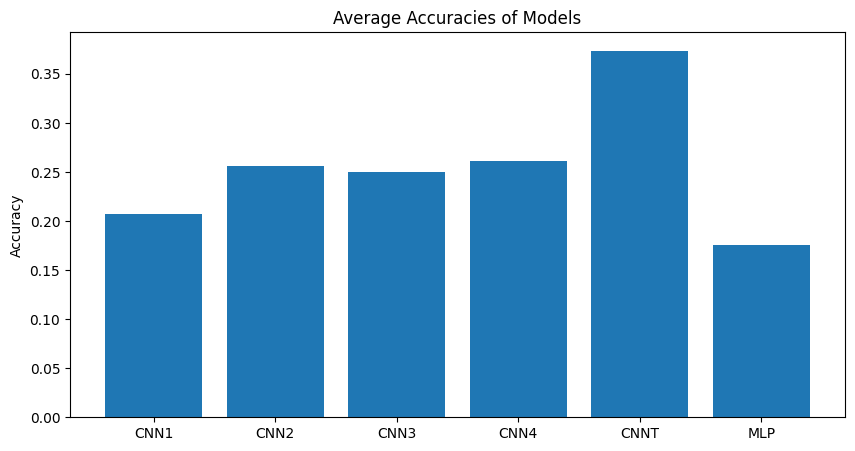

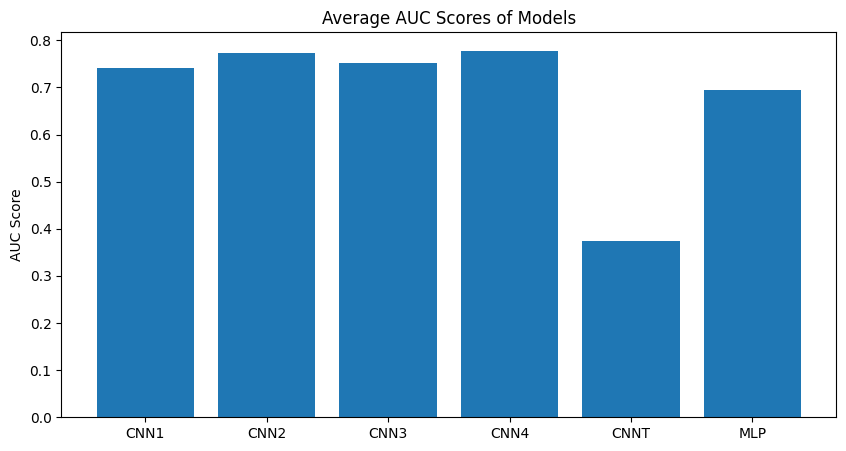

p-value for CNN1 vs CNN2 accuracies: 0.17742215390440785
p-value for CNN1 vs CNN3 accuracies: 0.2289176573387386
p-value for CNN1 vs CNN4 accuracies: 0.035329559642385974
p-value for CNN1 vs CNNT accuracies: 0.004953768270790387
p-value for CNN1 vs MLP accuracies: 0.013669518341088482
p-value for CNN2 vs CNN3 accuracies: 0.23894376653323968
p-value for CNN2 vs CNN4 accuracies: 0.7970650307801443
p-value for CNN2 vs CNNT accuracies: 0.08108833277384593
p-value for CNN2 vs MLP accuracies: 0.10332758743937882
p-value for CNN3 vs CNN4 accuracies: 0.661842142765167
p-value for CNN3 vs CNNT accuracies: 0.08866375550225183
p-value for CNN3 vs MLP accuracies: 0.1292539370803737
p-value for CNN4 vs CNNT accuracies: 0.009605407647874546
p-value for CNN4 vs MLP accuracies: 0.027275900875664946
p-value for CNNT vs MLP accuracies: 0.0063572049048300485


In [31]:
# Compute average AUC and accuracy for each model
avg_auc_cnn1 = np.mean(cnn1_auc_scores)
avg_auc_cnn2 = np.mean(cnn2_auc_scores)
avg_auc_cnn3 = np.mean(cnn3_auc_scores)
avg_auc_cnn4 = np.mean(cnn4_auc_scores)
avg_auc_cnnT = np.mean(cnnT_auc_scores)
avg_auc_mlp = np.mean(mlp_auc_scores)

avg_acc_cnn1 = np.mean(cnn1_accuracies)
avg_acc_cnn2 = np.mean(cnn2_accuracies)
avg_acc_cnn3 = np.mean(cnn3_accuracies)
avg_acc_cnn4 = np.mean(cnn4_accuracies)
avg_acc_cnnT = np.mean(cnnT_accuracies)
avg_acc_mlp = np.mean(mlp_accuracies)

# Print average AUC and accuracy for each model
print('Average AUC for CNN1:', avg_auc_cnn1)
print('Average AUC for CNN2:', avg_auc_cnn2)
print('Average AUC for CNN3:', avg_auc_cnn3)
print('Average AUC for CNN4:', avg_auc_cnn4)
print('Average AUC for CNNT:', avg_auc_cnnT)
print('Average AUC for MLP:', avg_auc_mlp)

print('Average accuracy for CNN1:', avg_acc_cnn1)
print('Average accuracy for CNN2:', avg_acc_cnn2)
print('Average accuracy for CNN3:', avg_acc_cnn3)
print('Average accuracy for CNN4:', avg_acc_cnn4)
print('Average accuracy for CNNT:', avg_acc_cnnT)
print('Average accuracy for MLP:', avg_acc_mlp)

import matplotlib.pyplot as plt

# Average accuracies
plt.figure(figsize=(10, 5))
plt.bar(['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'], [avg_acc_cnn1, avg_acc_cnn2, avg_acc_cnn3, avg_acc_cnn4, avg_acc_cnnT, avg_acc_mlp])
plt.title('Average Accuracies of Models')
plt.ylabel('Accuracy')
plt.show()

# Average AUC scores
plt.figure(figsize=(10, 5))
plt.bar(['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'], [avg_auc_cnn1, avg_auc_cnn2, avg_auc_cnn3, avg_auc_cnn4, avg_acc_cnnT, avg_auc_mlp])
plt.title('Average AUC Scores of Models')
plt.ylabel('AUC Score')
plt.show()

from scipy import stats

# List of all models' accuracies
accuracies = [cnn1_accuracies, cnn2_accuracies, cnn3_accuracies, cnn4_accuracies,cnnT_accuracies, mlp_accuracies]
labels = ['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP']

# Compare accuracies of all pairs of models
for i in range(len(accuracies)):
    for j in range(i+1, len(accuracies)):
        t_stat, p_val = stats.ttest_rel(accuracies[i], accuracies[j])
        print(f'p-value for {labels[i]} vs {labels[j]} accuracies: {p_val}')

### 2.4 Performance Summary Between Models and MLP

1. Average Accuracies:
- CNN1: 20.77%
- CNN2: 25.59%
- CNN3: 25.03%
- CNN4: 26.15%
- CNNT (Transfer): 37.38%
- MLP: 17.59%

2. Average AUC Scores:
- CNN1: 0.741
- CNN2: 0.772
- CNN3: 0.752
- CNN4: 0.778
- CNNT: 0.839
- MLP: 0.695

3. Statistical Significance (p-values < 0.05):
- CNN4 vs CNNT: 0.00961 (significant)
- CNN4 vs MLP: 0.0273 (significant)
- CNNT vs MLP: 0.00636 (significant)

### Key Findings:
1. Best Traditional Model: CNN4
   - Highest accuracy (26.15%)
   - Best AUC among non-transfer models (0.778)

2. Best Overall: Transfer Learning Model (CNNT)
   - Highest accuracy (37.38%)
   - Highest AUC score (0.839)
   - Statistically significant improvement over other models

3. Worst Performance: MLP
   - Lowest accuracy (17.59%)
   - Lowest AUC score (0.695)

We can see that our 4th CNN Model worked best among all the models we tested, suggesting that a larger dense layer, 48->98 filter layers, and 2 dropout layers created better performance amongst other models we tested. 


MLP performs significantly worse than other models we tested. This is due to the lack of pooling or convolution operations, which significantly improve overall accuracy and improve parameter efficency. Furthermore, there is no dropout, no feature extraction layers, or real feature learning. All of these contribute to worse performance from the MLP than other CNNs, and is reflected in the worst accuracy and AUC numbers among tested models.


# 3. Exceptional Work

In [27]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_transfer_model():
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add custom layers on top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    
    return model

In [28]:
# Resize and convert images to RGB
X_rgb = np.array([cv2.cvtColor(cv2.resize(img.astype('float32'), (128, 128)), cv2.COLOR_GRAY2RGB) for img in X])

# Stratified 10-fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
transfer_accuracies = []
transfer_auc_scores = []

for train_index, test_index in skf.split(X_rgb, y):
    X_train, X_test = X_rgb[train_index], X_rgb[test_index]
    y_train, y_test = y_ohe[train_index], y_ohe[test_index]
    
    transfer_model = create_transfer_model()
    history = transfer_model.fit(X_train, y_train, batch_size=32, epochs=50, shuffle=True, verbose=0, validation_data=(X_test, y_test))
    
    
    transfer_accuracies.append(history.history['val_accuracy'][-1])
    y_pred_probs = transfer_model.predict(X_test)
    transfer_auc_scores.append(roc_auc_score(y_test, y_pred_probs))

# Compute average accuracy and AUC
avg_acc_transfer = np.mean(transfer_accuracies)
avg_auc_transfer = np.mean(transfer_auc_scores)

print('Average accuracy for Transfer Learning Model:', avg_acc_transfer)
print('Average AUC for Transfer Learning Model:', avg_auc_transfer)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
Average accuracy for Transfer Learning Model: 0.49740222096443176
Average AUC for Transfer Learning Model: 0.8952896215788482


Average accuracy for Best Model: 0.2614811509847641
Average AUC for Best Model: 0.7780439563253086
Average accuracy for Transfer Learning Model: 0.49740222096443176
Average AUC for Transfer Learning Model: 0.8952896215788482


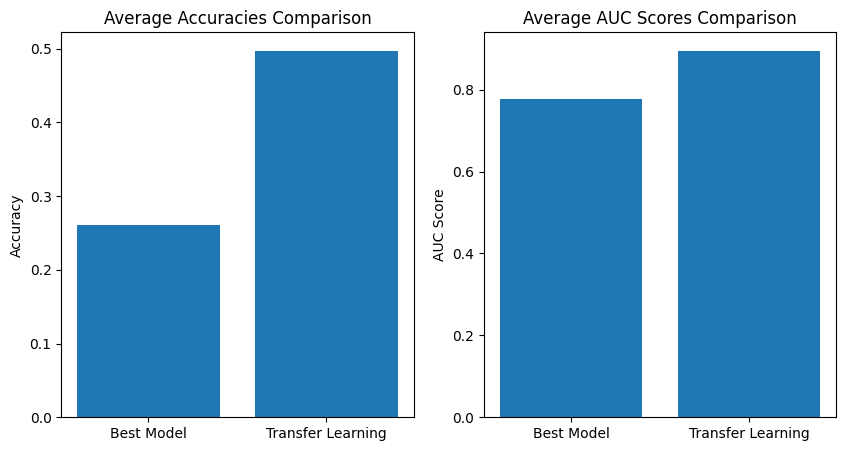

In [32]:
# Print average accuracy and AUC for the best model from above
print('Average accuracy for Best Model:', avg_acc_cnn4)
print('Average AUC for Best Model:', avg_auc_cnn4)

# Print average accuracy and AUC for the Transfer Learning Model
print('Average accuracy for Transfer Learning Model:', avg_acc_transfer)
print('Average AUC for Transfer Learning Model:', avg_auc_transfer)

# Visualize the comparison
labels = ['Best Model', 'Transfer Learning']
accuracies = [avg_acc_cnn4, avg_acc_transfer]
auc_scores = [avg_auc_cnn4, avg_auc_transfer]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, accuracies)
plt.title('Average Accuracies Comparison')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.bar(labels, auc_scores)
plt.title('Average AUC Scores Comparison')
plt.ylabel('AUC Score')

plt.show()

### 3.1 Comparison Between Models and Exceptional Work
As we can see, the transfer learning model did better than our best model (CNN4) between Average Accuracy and Average AUC. This can be explained as the pre-trained model has knowledge from larger datasets that is has been trained on prior. This means that the model has more exposure to image recognition, and the weights are more fine tuned. Furthermore, the other model has more parameters for learning, which improves performance. If we were to provide our CNN4 with more data, it is possible that the model would continue to improve to the level of the Transfer Learning model. 